# 🎬 Comparación de duración de películas por género 2

Los datos provienen del archivo `movies_limpio.csv`, que incluye información como título, año, duración, género principal, etc.


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.utils import resample
from scipy.stats import kruskal

# Configuraciones generales de estilo
sns.set_style(style="whitegrid")
#plt.rcParams["figure.figsize"] = (10, 6)

In [36]:

# Cargar el dataset
df = pd.read_csv("movies_limpio2.csv")
df['GeneroPrincipal'] = df['GeneroPrincipal'].astype('category')
# Mostrar primeras filas
df.head()

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description,Runtime_horas,GeneroPrincipal,Decada
0,1,The Shawshank Redemption,1994,9.3,80.0,Drama,2011509,Frank Darabont,142,28.34,Two imprisoned men bond over a number of years...,2.366667,Drama,1990
1,2,The Dark Knight,2008,9.0,84.0,"Action, Crime, Drama",1980200,Christopher Nolan,152,534.86,When the menace known as the Joker emerges fro...,2.533333,Action,2000
2,3,Inception,2010,8.8,74.0,"Action, Adventure, Sci-Fi",1760209,Christopher Nolan,148,292.58,A thief who steals corporate secrets through t...,2.466667,Action,2010
3,4,Fight Club,1999,8.8,66.0,Drama,1609459,David Fincher,139,37.03,An insomniac office worker and a devil-may-car...,2.316667,Drama,1990
4,5,Pulp Fiction,1994,8.9,94.0,"Crime, Drama",1570194,Quentin Tarantino,154,107.93,"The lives of two mob hitmen, a boxer, a gangst...",2.566667,Crime,1990


In [ ]:
df['Year'] = df['Year'].astype(int)
df['Decada'] = (df['Year'] // 10) * 10

In [34]:
df.shape

(7473, 14)

In [33]:
df.columns

Index(['Rank', 'Title', 'Year', 'Score', 'Metascore', 'Genre', 'Vote',
       'Director', 'Runtime', 'Revenue', 'Description', 'Runtime_horas',
       'GeneroPrincipal', 'Decada'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7473 entries, 0 to 7472
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Rank             7473 non-null   int64   
 1   Title            7473 non-null   object  
 2   Year             7473 non-null   int64   
 3   Score            7473 non-null   float64 
 4   Metascore        6125 non-null   float64 
 5   Genre            7473 non-null   object  
 6   Vote             7473 non-null   int64   
 7   Director         7473 non-null   object  
 8   Runtime          7473 non-null   int64   
 9   Revenue          7473 non-null   float64 
 10  Description      7473 non-null   object  
 11  Runtime_horas    7473 non-null   float64 
 12  GeneroPrincipal  7473 non-null   category
 13  Decada           7473 non-null   int64   
dtypes: category(1), float64(4), int64(5), object(4)
memory usage: 767.1+ KB


## Distribución de duración por género principal

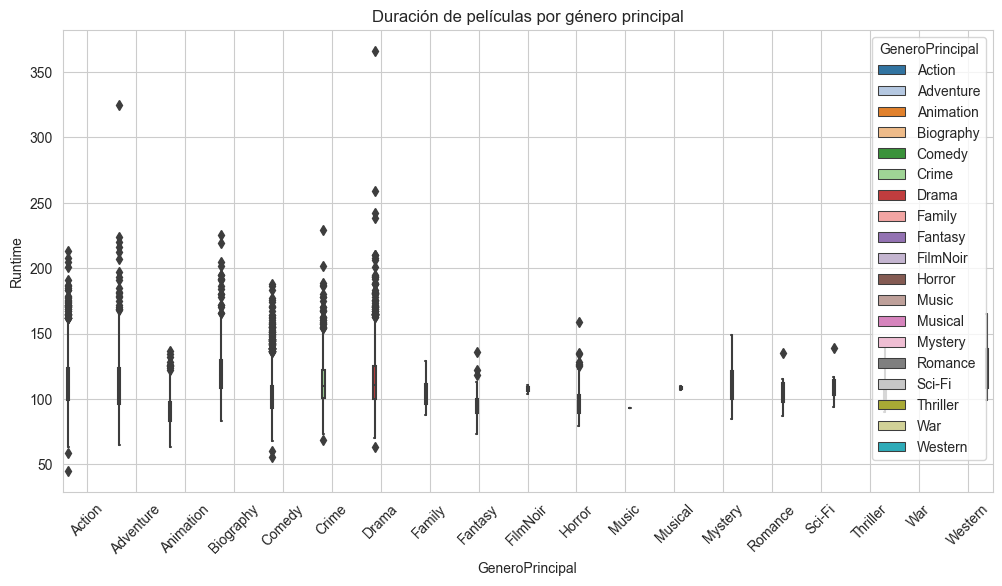

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='GeneroPrincipal', y='Runtime',hue = 'GeneroPrincipal' ,palette='tab20')
plt.xticks(rotation=45)
plt.title("Duración de películas por género principal")
plt.grid(True)
plt.show()

In [43]:
generos = ['Action', 'Drama', 'Comedy']

## ANOVA (Análisis de Varianza)
Comparamos duración entre más de dos géneros.

In [ ]:
from scipy.stats import f_oneway


f_stat, p_val = f_oneway(
    df[df['GeneroPrincipal'] == 'Drama']['Runtime'],
    df[df['GeneroPrincipal'] == 'Action']['Runtime'],
    df[df['GeneroPrincipal'] == 'Comedy']['Runtime']
)

print(f"Estadístico F: {f_stat:.3f}")
print(f"p-valor: {p_val:.4f}")
if p_val < 0.05:
    print("Hay diferencias significativas entre al menos dos géneros.")
else:
    print("No hay diferencias significativas.")

Estadístico F: 216.713
p-valor: 0.0000
Hay diferencias significativas entre al menos dos géneros.


La hipótesis nula (H₀):
La media de duración es igual en todos los géneros.

La hipótesis alternativa (H₁):
Al menos un género tiene una duración promedio distinta.

Interpretación del p-valor:

    Si p < 0.05 → Rechazas H₀
    ✅ Sí hay diferencias de duración entre al menos dos géneros.

    Si p ≥ 0.05 → No puedes rechazar H₀
    ❌ No tienes evidencia suficiente para decir que hay diferencias.

**¿Se puede confiar en este resultado?**

Sí, pero con reservas. ANOVA tiene supuestos que deberías verificar:
1. Normalidad de los datos por grupo: visualizar con histogramas/QQplots.

2. Varianzas iguales (homocedasticidad): Puedes usar levene() o bartlett() para probarlo.

3. Independencia de las observaciones: Esto depende del diseño del estudio (en este caso, si cada película es una unidad independiente, se cumple).

Si los datos no son normales o las varianzas son muy distintas, la ANOVA puede dar resultados poco confiables. En ese caso, es mejor usar Kruskal-Wallis, que no tiene esos requisitos.

1. Normalidad (por grupo)

Usamos la prueba de Shapiro-Wilk (para muestras < 5000) y también gráficos de histograma.

In [38]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Revisión de normalidad con Shapiro-Wilk
for genero in ['Drama', 'Action', 'Comedy']:
    grupo = df[df['GeneroPrincipal'] == genero]['Runtime']
    stat, p = shapiro(grupo)
    print(f"{genero}: Estadístico Shapiro-Wilk = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"→ Los datos de {genero} **NO** parecen normales.\n")
    else:
        print(f"→ Los datos de {genero} podrían ser normales.\n")


Drama: Estadístico Shapiro-Wilk = 0.873, p-valor = 0.0000
→ Los datos de Drama **NO** parecen normales.

Action: Estadístico Shapiro-Wilk = 0.943, p-valor = 0.0000
→ Los datos de Action **NO** parecen normales.

Comedy: Estadístico Shapiro-Wilk = 0.912, p-valor = 0.0000
→ Los datos de Comedy **NO** parecen normales.



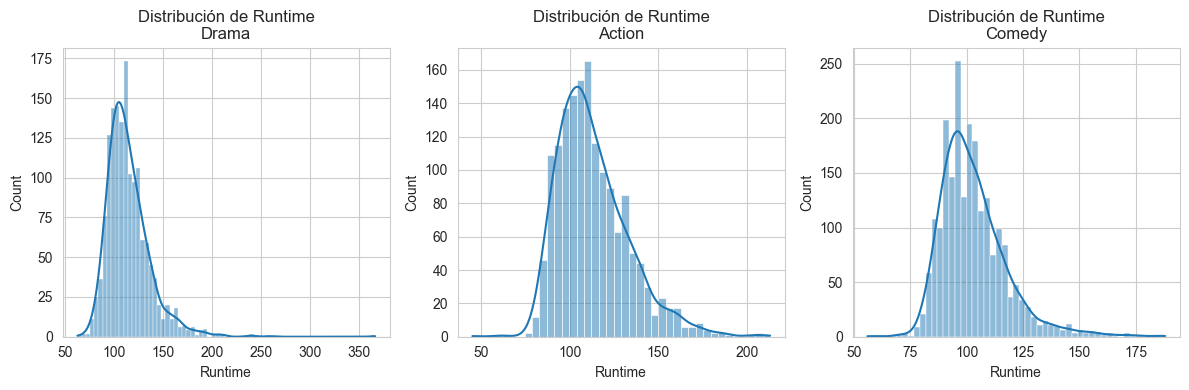

In [39]:
# Histogramas por grupo
plt.figure(figsize=(12, 4))
for i, genero in enumerate(['Drama', 'Action', 'Comedy']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[df['GeneroPrincipal'] == genero]['Runtime'], kde=True)
    plt.title(f'Distribución de Runtime\n{genero}')
plt.tight_layout()
plt.show()


2. Homocedasticidad (igualdad de varianzas)

Usamos la prueba de Levene:

In [40]:
from scipy.stats import levene

drama = df[df['GeneroPrincipal'] == 'Drama']['Runtime']
action = df[df['GeneroPrincipal'] == 'Action']['Runtime']
comedy = df[df['GeneroPrincipal'] == 'Comedy']['Runtime']

stat, p = levene(drama, action, comedy)
print(f"Prueba de Levene: Estadístico = {stat:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("→ Las varianzas NO son iguales entre los grupos.")
else:
    print("→ Las varianzas parecen iguales entre los grupos.")


Prueba de Levene: Estadístico = 78.620, p-valor = 0.0000
→ Las varianzas NO son iguales entre los grupos.


 3. Independencia
Asumimos que cada película es una observación independiente. Esto se cumple si no hay películas repetidas, ni series de la misma saga, ni datos correlacionados artificialmente.

## Prueba no paramétrica: Kruskal-Wallis
Compara las medianas de duración entre los 3 géneros.

In [41]:
from scipy.stats import kruskal

In [42]:
kruskal_test = kruskal(
    df.loc[df['GeneroPrincipal'] == 'Action', 'Runtime'],
    df.loc[df['GeneroPrincipal'] == 'Drama', 'Runtime'],
    df.loc[df['GeneroPrincipal'] == 'Comedy', 'Runtime']
)
print(f"Estadístico: {kruskal_test.statistic:.3f}")
print(f"p-valor: {kruskal_test.pvalue:.3f}")

Estadístico: 453.336
p-valor: 0.000


### Interpretación
- Si el **p-valor < 0.05**, se concluye que **al menos un grupo difiere** en la mediana.
- Si el **p-valor ≥ 0.05**, no hay evidencia suficiente para rechazar la hipótesis de que las medianas son iguales entre los grupos.


## Bootstrap para la mediana
Calculamos la mediana y su intervalo de confianza para cada género usando bootstrap.

In [ ]:
generos = ['Action', 'Drama', 'Comedy']

In [44]:

def bootstrap_median(df, num_samples=1000, ci=95):
    medians = []
    for _ in range(num_samples):
        sample = np.random.choice(df, size=len(df), replace=True)
        medians.append(np.median(sample))
    lower = np.percentile(medians, (100 - ci) / 2)
    upper = np.percentile(medians, 100 - (100 - ci) / 2)
    return np.median(medians), (lower, upper)

bootstrap_resultados = []
for genero in generos:
    grupo = df.loc[df['GeneroPrincipal'] == genero, 'Runtime'].values
    mediana, (li, ls) = bootstrap_median(grupo)
    bootstrap_resultados.append({
        'Género': genero,
        'Mediana Bootstrap': round(mediana, 2),
        'IC Inferior': round(li, 2),
        'IC Superior': round(ls, 2)
    })

pd.DataFrame(bootstrap_resultados)

,Género,Mediana Bootstrap,IC Inferior,IC Superior
0,Action,109.0,108.0,110.0
1,Drama,111.0,110.0,112.0
2,Comedy,100.0,100.0,101.0


**Esto significa:**

Si repitiéramos el muestreo miles de veces, la mediana de duración para cada género caería dentro del intervalo calculado aproximadamente el 95% del tiempo.

Las películas de "Drama" tienden a ser más largas (mediana: 111 min) que las de "Comedy" (mediana: 100 min), y esto no parece deberse al azar, ya que los intervalos no se traslapan.

1. Bootstrap no necesita supuestos de normalidad. Eso lo hace útil cuando no se cumplen los supuestos clásicos de pruebas t o ANOVA.
2. El intervalo de confianza (IC) no es garantía absoluta. El IC del 95% no asegura que la mediana real esté en ese rango con certeza, sino que en el 95% de los experimentos similares sí lo estará.
3. Comparaciones entre ICs deben hacerse con cuidado. Aunque los IC de "Drama" y "Comedy" no se traslapan, lo que sugiere una diferencia significativa en la mediana, esta comparación no reemplaza una prueba formal como Kruskal-Wallis.
4. Bootstrap de la mediana ≠ prueba de hipótesis. No es lo mismo que obtener un p-valor. Bootstrap te ayuda a estimar un parámetro y su variabilidad, pero no te dice directamente si hay diferencia significativa (aunque se puede extender para eso).

📝 **Ejercicio: Ahora con Score o con Revenue**
1. Seleccionar otro conjunto de géneros de películas
2. Verificar normalidad
3. Verificar homocedasticidad
4. Hacer test Kruskal-Wallis
Extra: Para estimar el valor de la mediana de cada género elegido, usar bootstrap.

In [46]:
list(df.GeneroPrincipal.unique())

['Drama',
 'Action',
 'Crime',
 'Adventure',
 'Biography',
 'Mystery',
 'Animation',
 'Comedy',
 'Horror',
 'Sci-Fi',
 'Western',
 'Family',
 'Fantasy',
 'Romance',
 'Musical',
 'FilmNoir',
 'Thriller',
 'Music',
 'War']

**1. Seleccionar otro conjunto de géneros de películas**

In [47]:
generos = ['Horror','Sci-Fi','Thriller']

**2. Verificar normalidad**

In [48]:
# Revisión de normalidad con Shapiro-Wilk
for genero in generos:
    grupo = df[df['GeneroPrincipal'] == genero]['Score']
    stat, p = shapiro(grupo)
    print(f"{genero}: Estadístico Shapiro-Wilk = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"→ Los datos de {genero} **NO** parecen normales.\n")
    else:
        print(f"→ Los datos de {genero} podrían ser normales.\n")

Horror: Estadístico Shapiro-Wilk = 0.997, p-valor = 0.6789
→ Los datos de Horror podrían ser normales.

Sci-Fi: Estadístico Shapiro-Wilk = 0.919, p-valor = 0.2772
→ Los datos de Sci-Fi podrían ser normales.

Thriller: Estadístico Shapiro-Wilk = 0.979, p-valor = 0.9744
→ Los datos de Thriller podrían ser normales.



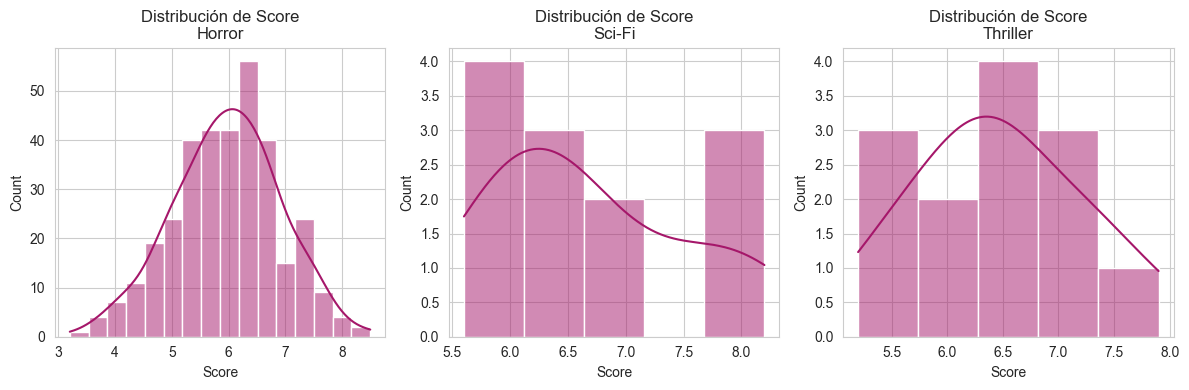

In [50]:
# Histogramas por grupo
plt.figure(figsize=(12, 4))
for i, genero in enumerate(generos):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[df['GeneroPrincipal'] == genero]['Score'], kde=True,color="#A5176A")
    plt.title(f'Distribución de Score\n{genero}')
plt.tight_layout()
plt.show()

**3. Verificar homocedasticidad**

In [51]:
horror = df[df['GeneroPrincipal'] == 'Horror']['Score']
scifi = df[df['GeneroPrincipal'] == 'Sci-Fi']['Score']
thriller = df[df['GeneroPrincipal'] == 'Thriller']['Score']

stat, p = levene(horror, scifi,thriller)
print(f"Prueba de Levene: Estadístico = {stat:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("→ Las varianzas NO son iguales entre los grupos.")
else:
    print("→ Las varianzas parecen iguales entre los grupos.")

Prueba de Levene: Estadístico = 0.735, p-valor = 0.4804
→ Las varianzas parecen iguales entre los grupos.


**4. Hacer test Kruskal-Wallis**

In [52]:
kruskal_test = kruskal(
    df[df['GeneroPrincipal'] == 'Horror']['Score'],
    df[df['GeneroPrincipal'] == 'Sci-Fi']['Score'],
    df[df['GeneroPrincipal'] == 'Thriller']['Score']
)
print(f"Estadístico: {kruskal_test.statistic:.3f}")
print(f"p-valor: {kruskal_test.pvalue:.3f}")

Estadístico: 8.819
p-valor: 0.012


### Interpretación
- Si el **p-valor < 0.05**, se concluye que **al menos un grupo difiere** en la mediana.
- Si el **p-valor ≥ 0.05**, no hay evidencia suficiente para rechazar la hipótesis de que las medianas son iguales entre los grupos.


**Extra 1: Bootstrap**

In [53]:
bootstrap_resultados = []
for genero in generos:
    grupo = df.loc[df['GeneroPrincipal'] == genero, 'Score'].values
    mediana, (li, ls) = bootstrap_median(grupo)
    bootstrap_resultados.append({
        'Género': genero,
        'Mediana Bootstrap': round(mediana, 2),
        'IC Inferior': round(li, 2),
        'IC Superior': round(ls, 2)
    })

pd.DataFrame(bootstrap_resultados)

,Género,Mediana Bootstrap,IC Inferior,IC Superior
0,Horror,6.00,5.9,6.1
1,Sci-Fi,6.45,6.0,7.3
2,Thriller,6.40,6.1,7.0


**Extra 2: ANOVA**

In [55]:
f_stat, p_val = f_oneway(
    df[df['GeneroPrincipal'] == 'Horror']['Score'],
    df[df['GeneroPrincipal'] == 'Sci-Fi']['Score'],
    df[df['GeneroPrincipal'] == 'Thriller']['Score']
)

print(f"Estadístico F: {f_stat:.3f}")
print(f"p-valor: {p_val:.4f}")
if p_val < 0.05:
    print("Hay diferencias significativas entre al menos dos géneros.")
else:
    print("No hay diferencias significativas.")

Estadístico F: 5.086
p-valor: 0.0066
Hay diferencias significativas entre al menos dos géneros.
